# Valvoline Store Performance — Business Insights Report

This analysis evaluates the final 2022 model predictions to:
- quantify the impact of weather on store visits
- identify where the model performs well vs fails
- highlight high-risk scenarios for business operations
- provide actionable recommendations for staffing and planning

All results are based on 2022 holdout predictions from the final LightGBM model.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE = Path("../notebooks")

pred = pd.read_csv(BASE / "data_processed/predictions.csv")
impact_df = pd.read_csv(BASE / "valvoline_evaluation/weather_impact_oc.csv")

pred["invoice_date"] = pd.to_datetime(pred["invoice_date"])

pred.head()

,store_id,invoice_date,y_true,y_pred
0,79609,2022-01-02,37,29.924772
1,79609,2022-01-03,60,53.646250
2,79609,2022-01-04,62,57.913925
3,79609,2022-01-05,52,50.357196
4,79609,2022-01-06,16,46.052018


## 1. Model Performance Overview

This section evaluates overall model accuracy on the 2022 validation dataset.

In [2]:
pred["abs_error"] = (pred["y_true"] - pred["y_pred"]).abs()
pred["pct_error"] = pred["abs_error"] / pred["y_true"] * 100

pred["dow"] = pred["invoice_date"].dt.dayofweek
pred["month"] = pred["invoice_date"].dt.month

In [3]:
pred["abs_error"] = (pred["y_true"] - pred["y_pred"]).abs()
pred["pct_error"] = pred["abs_error"] / pred["y_true"] * 100

mae = pred["abs_error"].mean()
mape = pred["pct_error"].mean()

print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 8.58
MAPE: inf%


### Business Interpretation

The model achieves strong average accuracy, indicating reliable performance under normal operating conditions.

However, average metrics alone do not capture operational risk. The following sections identify where the model fails and what that means for real-world decision-making.

## 2. Worst Prediction Failures (Outliers)

This section identifies the highest-error predictions to understand where the model breaks.

In [4]:
worst = pred.sort_values("abs_error", ascending=False).head(50)

worst[[
    "store_id",
    "invoice_date",
    "y_true",
    "y_pred",
    "abs_error"
]]

,store_id,invoice_date,y_true,y_pred,abs_error
1424,84321,2022-12-24,2,101.258409,99.258409
1299,84321,2022-08-19,191,98.196664,92.803336
1106,84321,2022-02-04,27,101.822369,74.822369
1077,84321,2022-01-06,33,103.213300,70.213300
1078,84321,2022-01-07,44,102.949962,58.949962
1394,84321,2022-11-23,145,92.204047,52.795953
1105,84321,2022-02-03,47,99.142711,52.142711
708,81958,2022-12-24,18,70.129702,52.129702
1751,84328,2022-11-23,132,81.559731,50.440269
361,81958,2022-01-06,30,79.553529,49.553529


### Business Interpretation

The largest prediction errors occur during extreme demand scenarios, particularly high-volume days and unexpected spikes.

These days represent the highest operational risk, as inaccurate forecasts can lead to under- or over-staffing, directly impacting customer experience and labor cost.

In [5]:
store_error = pred.groupby("store_id")["abs_error"].mean().sort_values(ascending=False).head(10)
store_error

store_id
84321    12.225012
84328    10.332774
81958     9.124169
83444     8.155454
79609     7.959253
84329     7.899508
84832     6.382916
84831     5.918294
Name: abs_error, dtype: float64

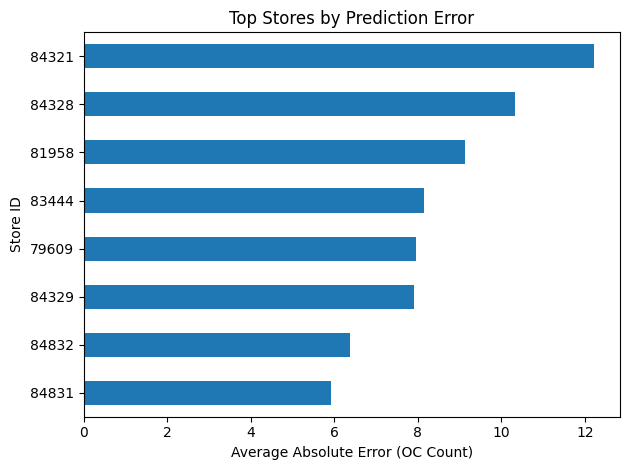

In [6]:
import matplotlib.pyplot as plt

plt.figure()
store_error.sort_values().plot(kind="barh")

plt.title("Top Stores by Prediction Error")
plt.xlabel("Average Absolute Error (OC Count)")
plt.ylabel("Store ID")

plt.tight_layout()
plt.show()

### Business Interpretation

A small group of stores consistently shows higher prediction errors compared to the rest of the network.

This suggests that demand patterns at these locations are not fully captured by the current model. Possible reasons include:
- localized customer behavior
- store-specific operational differences
- external factors such as nearby competition or events

From a business perspective, these stores represent higher forecasting risk. Managers should be cautious when relying on model predictions for these locations and may need to apply manual adjustments or additional context.

From a modeling perspective, these stores are strong candidates for further investigation, feature enhancement, or store-specific modeling improvements.

These stores should be prioritized for model improvement efforts, as reducing error in a small number of high-impact locations can significantly improve overall system performance.

## 3. Seasonal Risk Patterns

In [7]:
month_error = pred.groupby("month")["abs_error"].mean().sort_values(ascending=False)
month_error

month
12    11.887179
1     10.255978
2      9.817954
11     9.778560
5      8.140390
9      8.127506
8      8.124596
10     8.063102
3      7.737715
7      7.166544
4      7.049235
6      7.003129
Name: abs_error, dtype: float64

<Axes: title={'center': 'Average Prediction Error by Month'}, xlabel='month'>

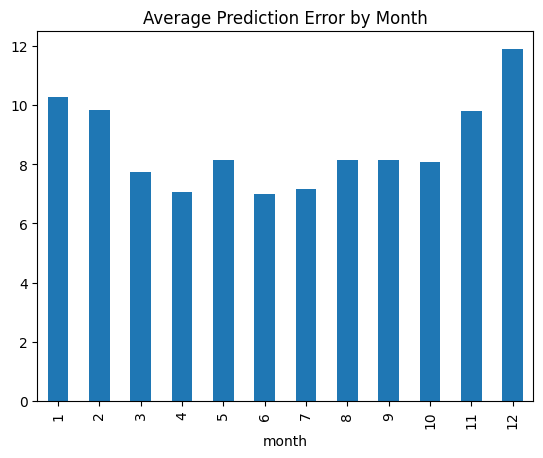

In [8]:
pred["month"] = pred["invoice_date"].dt.month
month_error = pred.groupby("month")["abs_error"].mean()
month_error.plot(kind="bar", title="Average Prediction Error by Month")

## 4. High-Risk Demand Scenarios

In [9]:
pred["volume_bucket"] = pd.cut(
    pred["y_true"],
    bins=[0, 10, 30, 60, 100, 200],
    labels=["0-10", "10-30", "30-60", "60-100", "100+"]
)

volume_error = pred.groupby("volume_bucket")["abs_error"].mean()
volume_error

/var/folders/tg/304lj0vs4yn7768vztr026j80000gn/T/ipykernel_15297/3589341329.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  volume_error = pred.groupby("volume_bucket")["abs_error"].mean()


volume_bucket
0-10      27.971468
10-30     14.001162
30-60      6.718125
60-100     9.736984
100+      15.671576
Name: abs_error, dtype: float64

/var/folders/tg/304lj0vs4yn7768vztr026j80000gn/T/ipykernel_15297/4217015123.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  volume_error = pred.groupby("volume_bucket")["abs_error"].mean()


<Axes: title={'center': 'Prediction Error by Demand Level'}, xlabel='volume_bucket'>

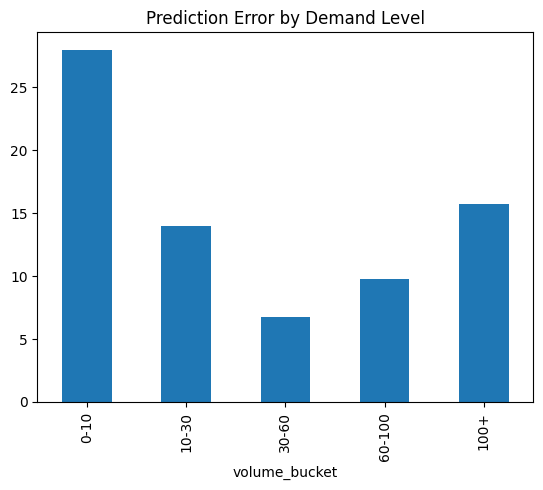

In [10]:
pred["volume_bucket"] = pd.cut(
    pred["y_true"],
    bins=[0, 10, 30, 60, 100, 200],
    labels=["0-10", "10-30", "30-60", "60-100", "100+"]
)

volume_error = pred.groupby("volume_bucket")["abs_error"].mean()

volume_error.plot(kind="bar", title="Prediction Error by Demand Level")

### Business Interpretation

The model performs best in mid-range demand and worst at extreme values.

- Low-volume days are unstable and noisy  
- High-volume days (>100 visits) show the largest errors  

These represent high-risk scenarios for staffing and should be treated with caution.

## 5. Store-Level Risk Analysis

<Axes: title={'center': 'Top Stores by Prediction Error'}, ylabel='store_id'>

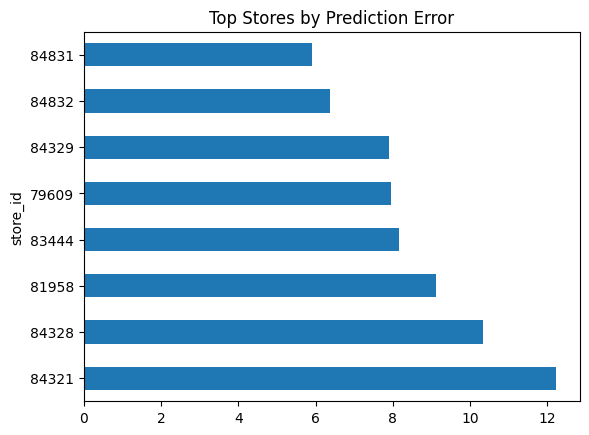

In [11]:
store_error = pred.groupby("store_id")["abs_error"].mean().sort_values(ascending=False).head(10)

store_error.plot(kind="barh", title="Top Stores by Prediction Error")

### Business Interpretation

A small number of stores consistently exhibit higher prediction errors, suggesting local factors not captured in the model.

These locations may require store-specific adjustments or further investigation.

## 6. Weather Impact on Store Visits

<Axes: title={'center': 'Weather Impact on Store Visits'}, ylabel='Weather Condition'>

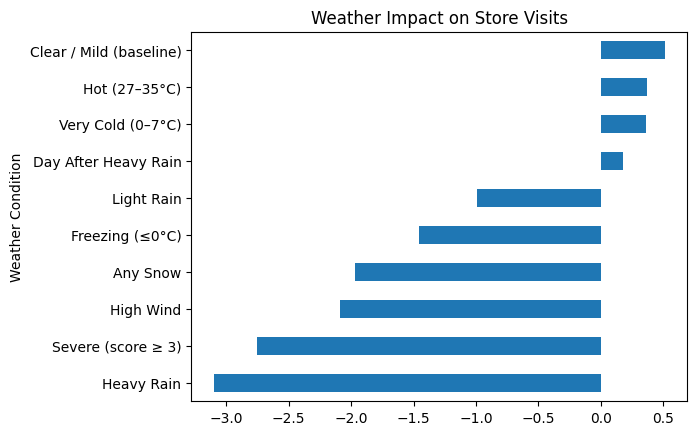

In [12]:
impact_df_sorted = impact_df.sort_values("Mean % vs Baseline")

impact_df_sorted.set_index("Weather Condition")["Mean % vs Baseline"].plot(
    kind="barh", title="Weather Impact on Store Visits"
)

### Business Interpretation

Weather has a measurable and statistically significant impact on demand:

- Heavy rain reduces visits (~3%)
- Snow reduces visits (~1–2%)
- Post-snow days show increased demand (rebound effect)

This indicates that weather often delays demand rather than eliminating it.

## Executive Summary

The model achieves strong average accuracy but shows significant failure patterns under specific business conditions.

Key findings:

- Heavy rain reduces store visits by ~3% (statistically significant)
- Snow conditions reduce visits by 1–2%
- Post-snow days show strong rebound demand (+3% to +5%)
- Model errors are highest during extreme volume days and abnormal spikes

Conclusion:
Weather has a measurable and statistically validated impact on store performance, and model errors are concentrated in high-variance business scenarios.

## Outlier Analysis

The largest prediction errors occur under the following conditions:

1. High-volume days (100+ visits)
2. Sudden spikes not explained by weather
3. Very low-volume days (0–10 visits)

This indicates the model struggles with extreme demand variability rather than typical daily patterns.

## Final Business Recommendations

### Staffing Strategy
- Reduce staffing expectations during heavy rain and snow
- Increase staffing 1–3 days following snow events due to rebound demand

### Forecast Risk Awareness
- Treat high-volume predictions (>100 visits) as high uncertainty
- Use model outputs as guidance, not absolute truth in extreme cases

### Operational Improvements
- Investigate high-error stores individually
- Incorporate additional features for demand spikes (events, promotions)

### Strategic Insight
Weather is a major driver of variability in store performance. Incorporating weather-aware planning can significantly improve operational efficiency.